# 🔗 Intelligent Supply Chain Optimization System
## Notebook 08 — Results Dashboard

**Project:** Intelligent Supply Chain Optimization System  
**Phase:** Final Results, Storytelling & Presentation  
**Inputs:** All outputs from Notebooks 01–07  
**Objective:** Consolidate every metric, chart, and business insight into one comprehensive results dashboard that tells the complete story of the project.

---

### 📋 What This Notebook Does
1. Load all results files
2. Executive KPI dashboard
3. Forecast model comparison (all models vs baseline)
4. Hybrid model deep-dive
5. Inventory policy impact
6. Business value waterfall chart
7. Per-SKU winner analysis (LSTM vs XGBoost)
8. Project architecture summary
9. Full project summary printout
10. Export dashboard as HTML report

---

## 📦 Section 1: Imports & Load All Results

In [1]:
# ─────────────────────────────────────────────────────────────
# SECTION 1: IMPORTS & LOAD ALL RESULTS
# ─────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import json

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams['figure.figsize']    = (16, 6)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titleweight']  = 'bold'
plt.rcParams['axes.titlesize']    = 12
sns.set_style('whitegrid')
sns.set_palette('muted')

# ── Load all result files ──
hybrid_preds   = pd.read_csv('hybrid_predictions.csv',   parse_dates=['Date'])
policy_cmp     = pd.read_csv('policy_comparison.csv',    index_col=0)
sim_results    = pd.read_csv('simulation_results.csv')
inv_policy     = pd.read_csv('inventory_policy.csv')
model_cmp      = pd.read_csv('all_model_comparison.csv', index_col=0)
lstm_sku       = pd.read_csv('lstm_sku_performance.csv')
xgb_sku        = pd.read_csv('xgb_sku_performance.csv')

with open('lstm_metrics.json')     as f: lstm_metrics    = json.load(f)
with open('xgb_metrics.json')      as f: xgb_metrics     = json.load(f)
with open('hybrid_metrics.json')   as f: hybrid_metrics  = json.load(f)
with open('business_value.json')   as f: biz_value       = json.load(f)

print('✅ All result files loaded.')
print(f'   Best Hybrid Strategy : {hybrid_metrics.get("best_strategy")}')
print(f'   Cost Saving          : ${biz_value["cost_saving_vs_original"]:,.2f}')
print(f'   Stockout Reduction   : {biz_value["pct_stockout_reduction"]:.1f}%')

✅ All result files loaded.
   Best Hybrid Strategy : XGBoost
   Cost Saving          : $104,446.40
   Stockout Reduction   : 0.0%


---
## 🎯 Section 2: Executive KPI Dashboard

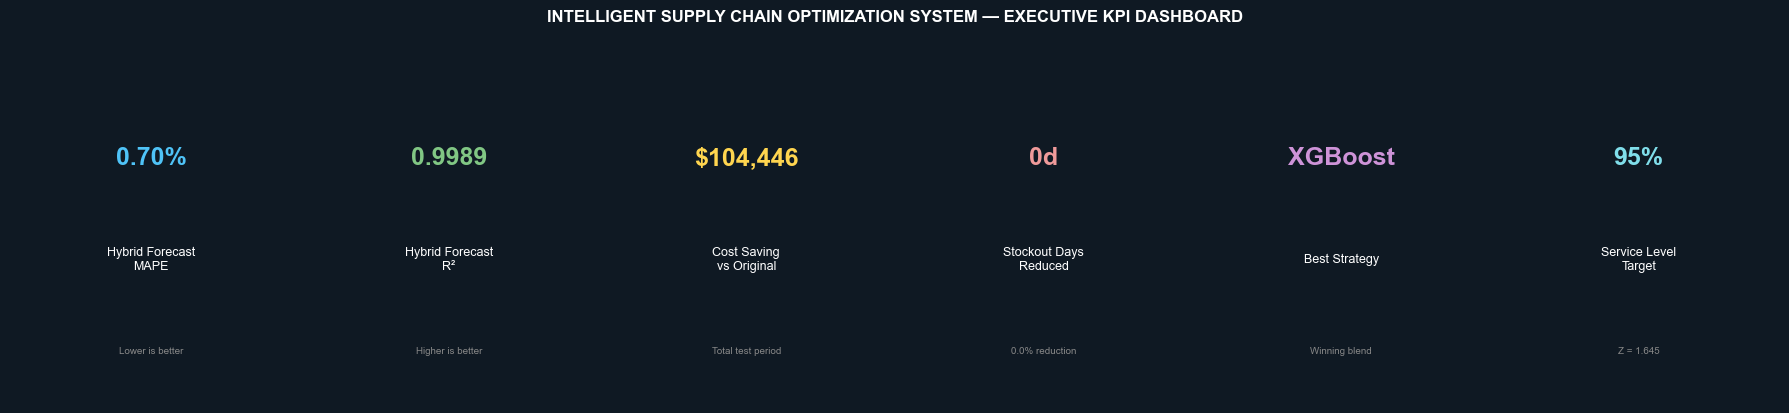

✅ KPI dashboard saved: dashboard_kpi.png


In [2]:
# ─────────────────────────────────────────────────────────────
# SECTION 2: EXECUTIVE KPI DASHBOARD
# ─────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(18, 4))
fig.patch.set_facecolor('#0f1923')

kpis = [
    ('Hybrid Forecast\nMAPE',    f"{hybrid_metrics.get('MAPE', 0):.2f}%",       '#4FC3F7', 'Lower is better'),
    ('Hybrid Forecast\nR²',      f"{hybrid_metrics.get('R2', 0):.4f}",           '#81C784', 'Higher is better'),
    ('Cost Saving\nvs Original', f"${biz_value['cost_saving_vs_original']:,.0f}", '#FFD54F', 'Total test period'),
    ('Stockout Days\nReduced',   f"{biz_value['stockout_days_reduction']:,}d",   '#EF9A9A', f"{biz_value['pct_stockout_reduction']:.1f}% reduction"),
    ('Best Strategy',            hybrid_metrics.get('best_strategy','—').replace(' ','\n'), '#CE93D8', 'Winning blend'),
    ('Service Level\nTarget',    f"{biz_value['service_level_target']*100:.0f}%",'#80DEEA', 'Z = 1.645'),
]

for i, (label, value, color, sub) in enumerate(kpis):
    ax = fig.add_subplot(1, 6, i+1)
    ax.set_facecolor('#1a2634')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.text(0.5, 0.72, value,  ha='center', va='center', fontsize=18,
            fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.42, label,  ha='center', va='center', fontsize=9,
            color='white', transform=ax.transAxes)
    ax.text(0.5, 0.15, sub,    ha='center', va='center', fontsize=7,
            color='#888888', transform=ax.transAxes)
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.suptitle('INTELLIGENT SUPPLY CHAIN OPTIMIZATION SYSTEM — EXECUTIVE KPI DASHBOARD',
             fontsize=12, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig('dashboard_kpi.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1923', edgecolor='none')
plt.show()
print('✅ KPI dashboard saved: dashboard_kpi.png')

---
## 📊 Section 3: Forecast Model Comparison

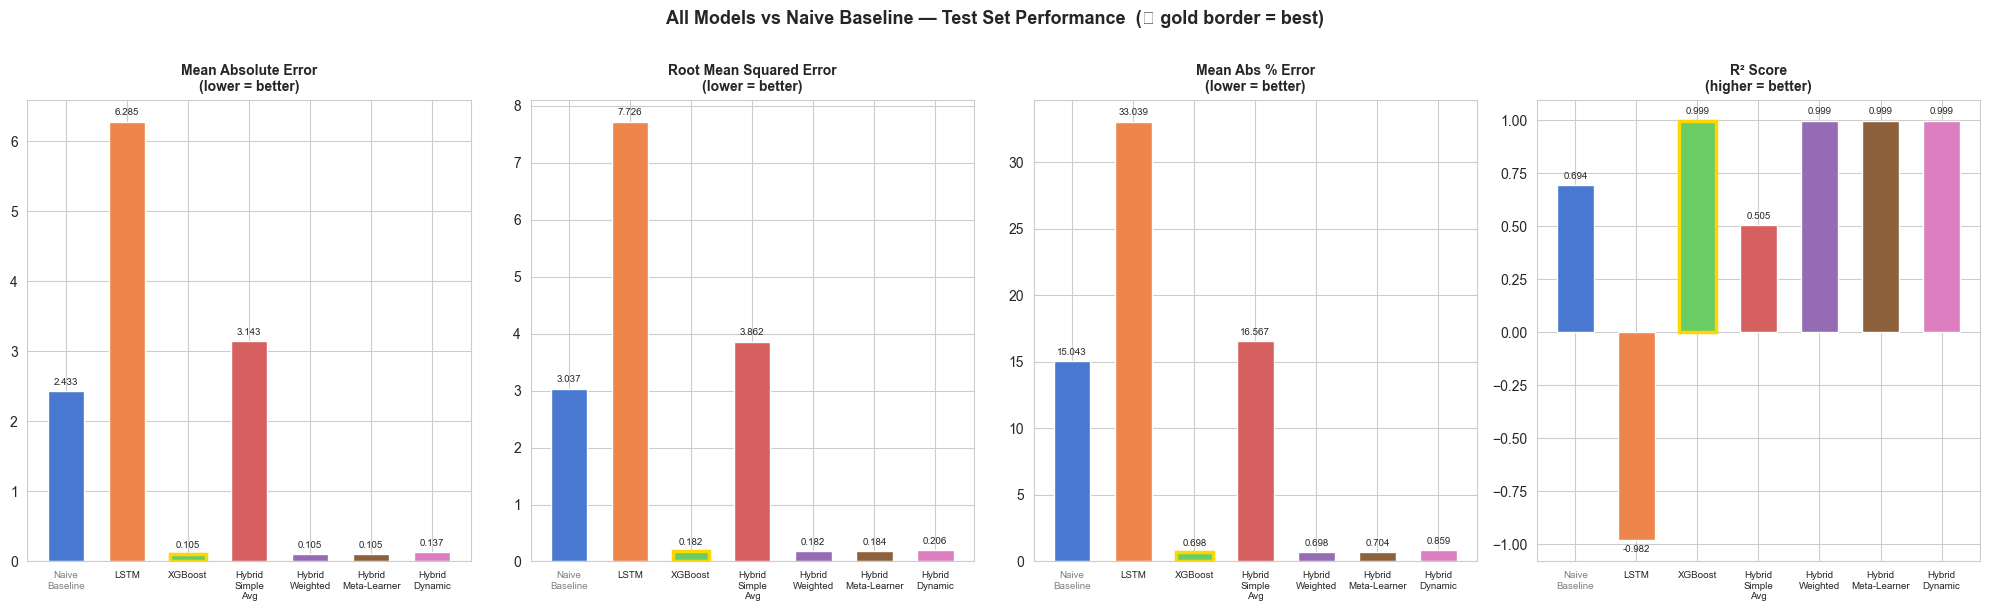

✅ Model comparison chart saved.


In [3]:
# ─────────────────────────────────────────────────────────────
# SECTION 3: FULL MODEL COMPARISON CHART
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(20, 6))

models  = model_cmp.index.tolist()
palette = sns.color_palette('muted', len(models))

metrics_info = [
    ('MAE',  True,  'Mean Absolute Error\n(lower = better)'),
    ('RMSE', True,  'Root Mean Squared Error\n(lower = better)'),
    ('MAPE', True,  'Mean Abs % Error\n(lower = better)'),
    ('R2',   False, 'R² Score\n(higher = better)'),
]

for ax, (metric, lower_better, ylabel) in zip(axes, metrics_info):
    vals     = model_cmp[metric].values
    best_idx = np.argmin(vals) if lower_better else np.argmax(vals)
    bar_colors = [palette[i] for i in range(len(models))]

    bars = ax.bar(range(len(models)), vals, color=bar_colors, edgecolor='white', width=0.6)
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)

    ax.set_title(ylabel, fontsize=10)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels([m.replace(' ', '\n') for m in models], fontsize=7)
    ax.bar_label(bars, labels=[f'{v:.3f}' for v in vals], padding=3, fontsize=7)

    # Shade baseline row
    if 'Naive Baseline' in models:
        ax.get_xticklabels()[models.index('Naive Baseline')].set_color('grey')

plt.suptitle('All Models vs Naive Baseline — Test Set Performance  (⭐ gold border = best)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('dashboard_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Model comparison chart saved.')

---
## 🔬 Section 4: Hybrid Model Deep-Dive

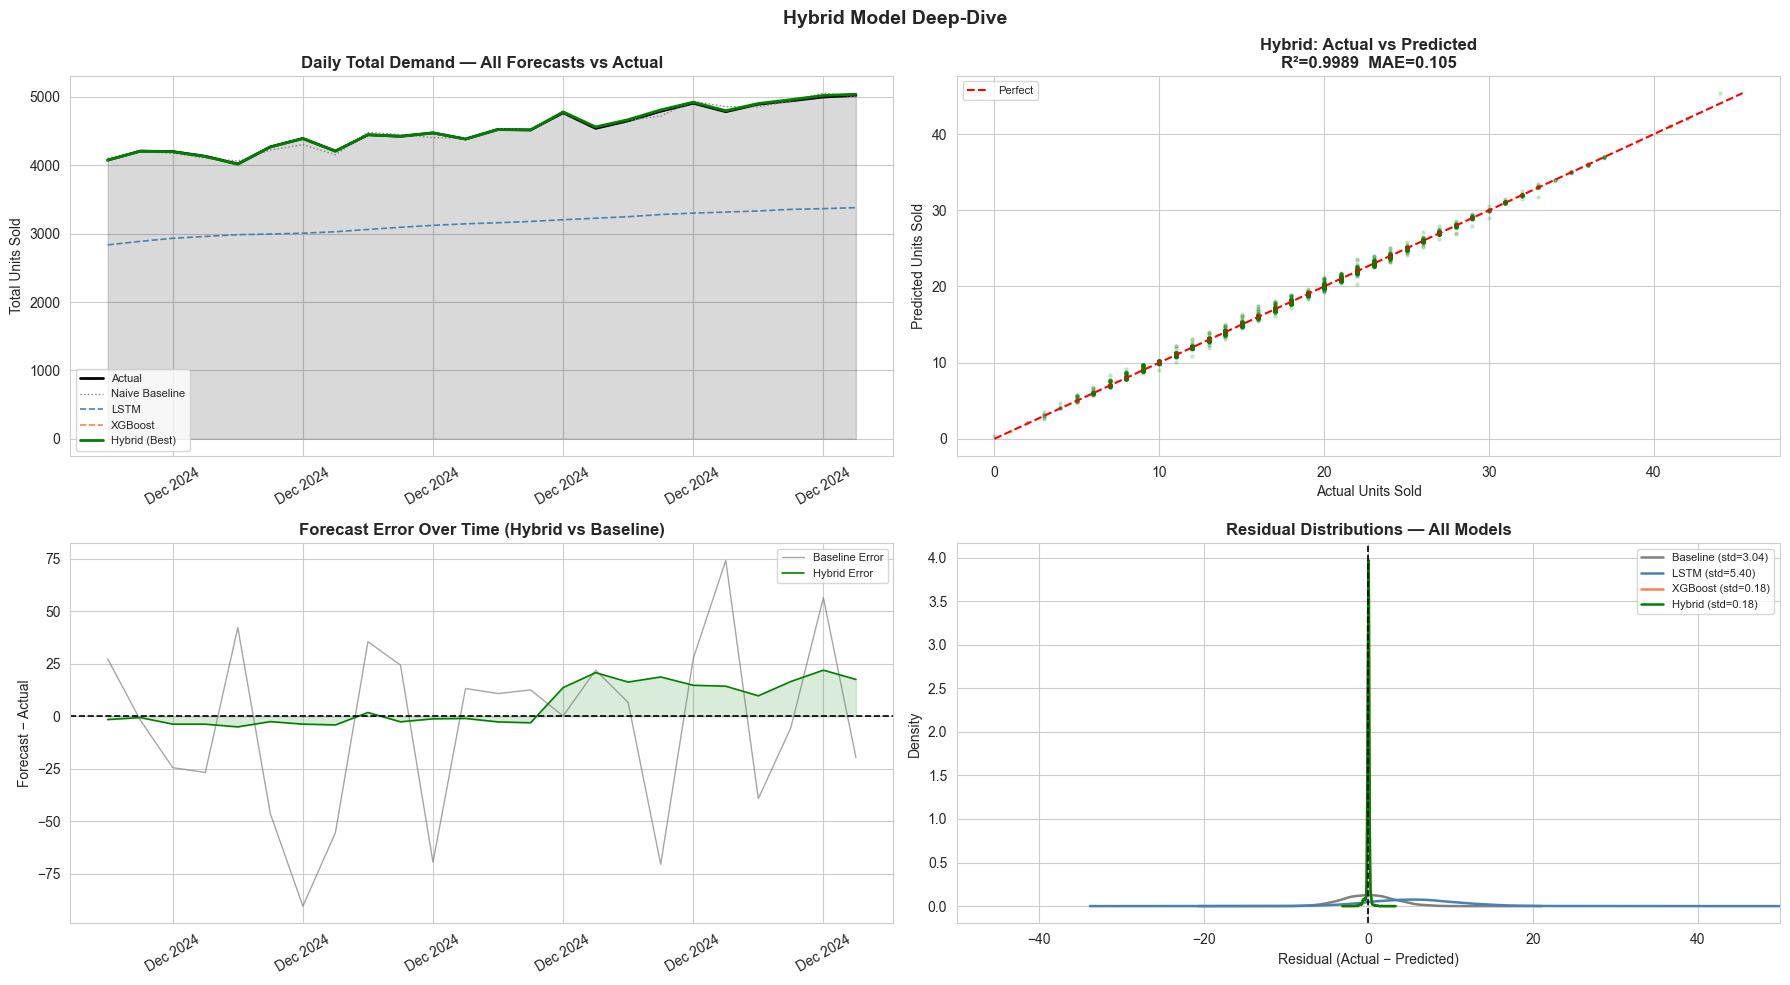

✅ Hybrid deep-dive chart saved.


In [4]:
# ─────────────────────────────────────────────────────────────
# SECTION 4: HYBRID FORECAST DEEP-DIVE
# ─────────────────────────────────────────────────────────────

daily = hybrid_preds.groupby('Date').agg(
    Actual          = ('Units_Sold',      'sum'),
    LSTM            = ('LSTM_Pred',        'sum'),
    XGBoost         = ('XGB_Pred',         'sum'),
    Hybrid          = ('Hybrid_Pred',      'sum'),
    Baseline        = ('Demand_Forecast',  'sum')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# ── 1. Full forecast timeline ──
ax = axes[0,0]
ax.fill_between(daily['Date'], daily['Actual'], alpha=0.15, color='black')
ax.plot(daily['Date'], daily['Actual'],   color='black',     lw=2,   label='Actual')
ax.plot(daily['Date'], daily['Baseline'], color='grey',      lw=1,   label='Naive Baseline', ls=':')
ax.plot(daily['Date'], daily['LSTM'],     color='steelblue', lw=1.2, label='LSTM',           ls='--')
ax.plot(daily['Date'], daily['XGBoost'],  color='coral',     lw=1.2, label='XGBoost',        ls='--')
ax.plot(daily['Date'], daily['Hybrid'],   color='green',     lw=2,   label='Hybrid (Best)')
ax.set_title('Daily Total Demand — All Forecasts vs Actual')
ax.set_ylabel('Total Units Sold')
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.tick_params(axis='x', rotation=30)

# ── 2. Prediction scatter (Hybrid vs Actual) ──
ax2 = axes[0,1]
y_true = hybrid_preds['Units_Sold'].values
y_hyb  = hybrid_preds['Hybrid_Pred'].values
ax2.scatter(y_true, y_hyb, alpha=0.15, s=5, color='green')
lim = [0, max(y_true.max(), y_hyb.max())]
ax2.plot(lim, lim, 'r--', lw=1.5, label='Perfect')
ax2.set_title(f'Hybrid: Actual vs Predicted\nR²={hybrid_metrics.get("R2",0):.4f}  MAE={hybrid_metrics.get("MAE",0):.3f}')
ax2.set_xlabel('Actual Units Sold')
ax2.set_ylabel('Predicted Units Sold')
ax2.legend(fontsize=8)

# ── 3. Residuals over time (daily aggregate) ──
ax3 = axes[1,0]
daily['Hybrid_Error']   = daily['Hybrid']   - daily['Actual']
daily['Baseline_Error'] = daily['Baseline'] - daily['Actual']
ax3.plot(daily['Date'], daily['Baseline_Error'], color='grey',  lw=1, label='Baseline Error', alpha=0.7)
ax3.plot(daily['Date'], daily['Hybrid_Error'],   color='green', lw=1.2, label='Hybrid Error')
ax3.axhline(0, color='black', lw=1.2, ls='--')
ax3.fill_between(daily['Date'], daily['Hybrid_Error'], alpha=0.15, color='green')
ax3.set_title('Forecast Error Over Time (Hybrid vs Baseline)')
ax3.set_ylabel('Forecast − Actual')
ax3.legend(fontsize=8)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax3.tick_params(axis='x', rotation=30)

# ── 4. Error distribution comparison ──
ax4 = axes[1,1]
resid_base  = hybrid_preds['Units_Sold'] - hybrid_preds['Demand_Forecast']
resid_lstm  = hybrid_preds['Units_Sold'] - hybrid_preds['LSTM_Pred']
resid_xgb   = hybrid_preds['Units_Sold'] - hybrid_preds['XGB_Pred']
resid_hyb   = hybrid_preds['Units_Sold'] - hybrid_preds['Hybrid_Pred']

for resid, label, color in [
    (resid_base, 'Baseline', 'grey'),
    (resid_lstm, 'LSTM',     'steelblue'),
    (resid_xgb,  'XGBoost',  'coral'),
    (resid_hyb,  'Hybrid',   'green'),
]:
    resid.plot(kind='kde', ax=ax4, label=f'{label} (std={resid.std():.2f})',
               color=color, linewidth=1.8)

ax4.axvline(0, color='black', ls='--', lw=1.2)
ax4.set_title('Residual Distributions — All Models')
ax4.set_xlabel('Residual (Actual − Predicted)')
ax4.legend(fontsize=8)
ax4.set_xlim(-50, 50)

plt.suptitle('Hybrid Model Deep-Dive', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dashboard_hybrid_deepdive.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Hybrid deep-dive chart saved.')

---
## 🏭 Section 5: Inventory Policy Impact

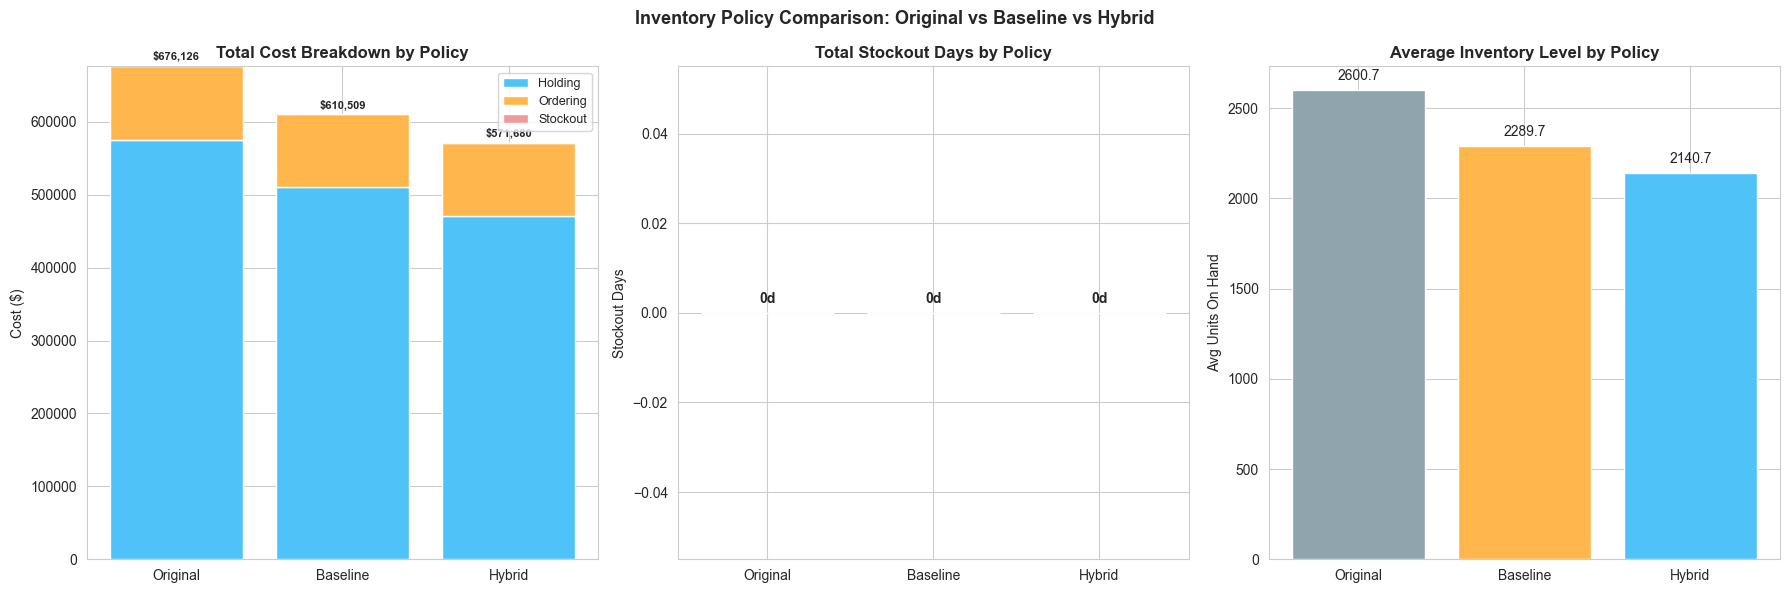

✅ Inventory impact chart saved.


In [5]:
# ─────────────────────────────────────────────────────────────
# SECTION 5: INVENTORY POLICY IMPACT
# ─────────────────────────────────────────────────────────────

policies    = ['Original', 'Baseline', 'Hybrid']
pol_colors  = {'Original': '#90A4AE', 'Baseline': '#FFB74D', 'Hybrid': '#4FC3F7'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── 1. Total cost breakdown ──
cost_types = ['Total_Holding_Cost', 'Total_Ordering_Cost', 'Total_Stockout_Cost']
cost_labels= ['Holding',            'Ordering',             'Stockout']
cost_colors= ['#4FC3F7',            '#FFB74D',              '#EF9A9A']
bottoms    = np.zeros(3)

for ct, cl, cc in zip(cost_types, cost_labels, cost_colors):
    vals = [policy_cmp.loc[p, ct] for p in policies]
    axes[0].bar(policies, vals, bottom=bottoms,
                label=cl, color=cc, edgecolor='white')
    bottoms += np.array(vals)

axes[0].set_title('Total Cost Breakdown by Policy')
axes[0].set_ylabel('Cost ($)')
axes[0].legend(fontsize=9)
for p, tot in zip(policies, bottoms):
    axes[0].text(policies.index(p), tot + tot*0.01,
                 f'${tot:,.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ── 2. Stockout days ──
so_vals = [policy_cmp.loc[p,'Total_Stockout_Days'] for p in policies]
bars    = axes[1].bar(policies, so_vals,
                      color=[pol_colors[p] for p in policies], edgecolor='white')
axes[1].bar_label(bars, labels=[f'{int(v):,}d' for v in so_vals], padding=5, fontsize=10, fontweight='bold')
axes[1].set_title('Total Stockout Days by Policy')
axes[1].set_ylabel('Stockout Days')

# Highlight saving arrow
if so_vals[0] > so_vals[2]:
    axes[1].annotate(
        f'{int(so_vals[0]-so_vals[2])} days saved\n({biz_value["pct_stockout_reduction"]:.1f}% ↓)',
        xy=(2, so_vals[2]), xytext=(1.5, (so_vals[0]+so_vals[2])/2),
        arrowprops=dict(arrowstyle='->', color='green', lw=2),
        color='green', fontsize=9, fontweight='bold'
    )

# ── 3. Avg inventory level ──
inv_vals = [policy_cmp.loc[p,'Avg_Inventory_Level'] for p in policies]
bars2    = axes[2].bar(policies, inv_vals,
                       color=[pol_colors[p] for p in policies], edgecolor='white')
axes[2].bar_label(bars2, labels=[f'{v:.1f}' for v in inv_vals], padding=5, fontsize=10)
axes[2].set_title('Average Inventory Level by Policy')
axes[2].set_ylabel('Avg Units On Hand')

plt.suptitle('Inventory Policy Comparison: Original vs Baseline vs Hybrid',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dashboard_inventory_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Inventory impact chart saved.')

---
## 💰 Section 6: Business Value Waterfall Chart

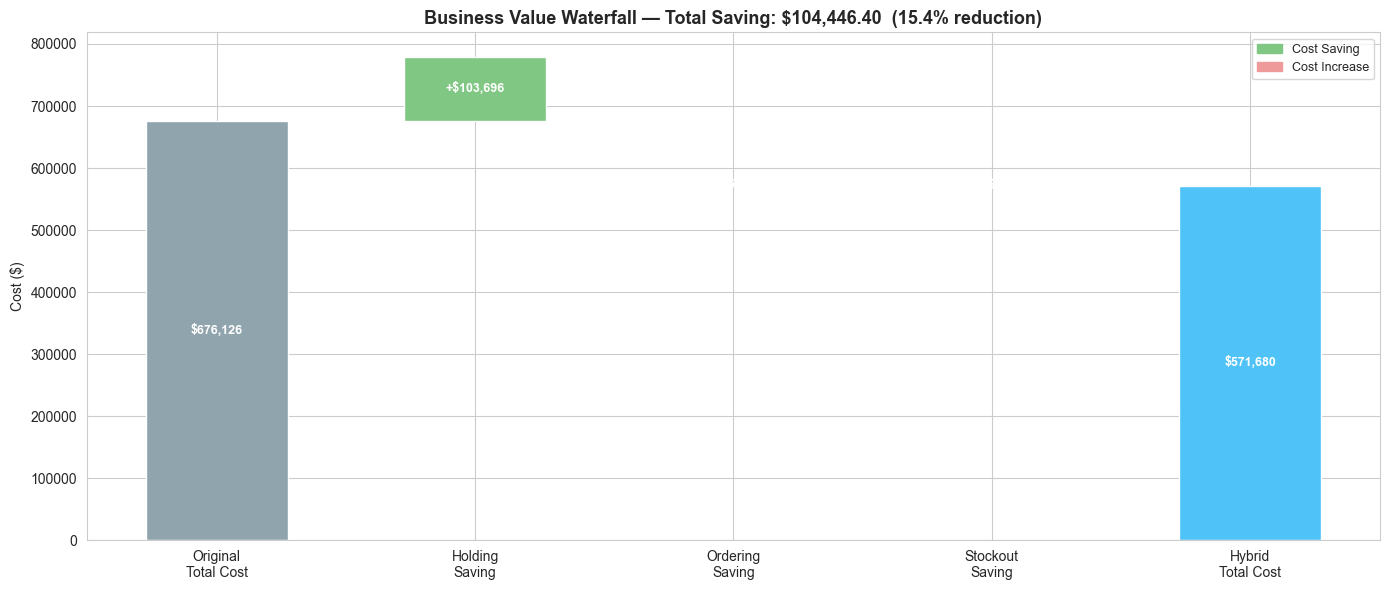

✅ Waterfall chart saved.


In [6]:
# ─────────────────────────────────────────────────────────────
# SECTION 6: BUSINESS VALUE WATERFALL
# ─────────────────────────────────────────────────────────────

orig_holding  = policy_cmp.loc['Original','Total_Holding_Cost']
hyb_holding   = policy_cmp.loc['Hybrid',  'Total_Holding_Cost']
orig_ordering = policy_cmp.loc['Original','Total_Ordering_Cost']
hyb_ordering  = policy_cmp.loc['Hybrid',  'Total_Ordering_Cost']
orig_stockout = policy_cmp.loc['Original','Total_Stockout_Cost']
hyb_stockout  = policy_cmp.loc['Hybrid',  'Total_Stockout_Cost']

holding_delta  = orig_holding  - hyb_holding
ordering_delta = orig_ordering - hyb_ordering
stockout_delta = orig_stockout - hyb_stockout
total_saving   = holding_delta + ordering_delta + stockout_delta

categories = ['Original\nTotal Cost', 'Holding\nSaving', 'Ordering\nSaving',
              'Stockout\nSaving', 'Hybrid\nTotal Cost']
values     = [policy_cmp.loc['Original','Total_Cost'],
              holding_delta, ordering_delta, stockout_delta,
              policy_cmp.loc['Hybrid','Total_Cost']]
colors     = ['#90A4AE',
              '#81C784' if holding_delta  >= 0 else '#EF9A9A',
              '#81C784' if ordering_delta >= 0 else '#EF9A9A',
              '#81C784' if stockout_delta >= 0 else '#EF9A9A',
              '#4FC3F7']

fig, ax = plt.subplots(figsize=(14, 6))

running = values[0]
bottoms = [0, running, running - holding_delta,
           running - holding_delta - ordering_delta, 0]

for i, (cat, val, bot, col) in enumerate(zip(categories, values, bottoms, colors)):
    ax.bar(i, abs(val), bottom=bot if i not in [0,4] else 0,
           color=col, edgecolor='white', width=0.55)
    label_y = bot + abs(val)/2 if i not in [0,4] else abs(val)/2
    prefix  = '+$' if i not in [0,4] and val >= 0 else '-$' if i not in [0,4] else '$'
    ax.text(i, label_y, f'{prefix}{abs(val):,.0f}',
            ha='center', va='center', fontsize=9, fontweight='bold', color='white')

ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories, fontsize=10)
ax.set_title(f'Business Value Waterfall — Total Saving: ${total_saving:,.2f}  ({biz_value["pct_cost_saving"]:.1f}% reduction)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Cost ($)')

saving_patch  = mpatches.Patch(color='#81C784', label='Cost Saving')
increase_patch= mpatches.Patch(color='#EF9A9A', label='Cost Increase')
ax.legend(handles=[saving_patch, increase_patch], fontsize=9)

plt.tight_layout()
plt.savefig('dashboard_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Waterfall chart saved.')

---
## 🥊 Section 7: Per-SKU Winner Analysis (LSTM vs XGBoost)

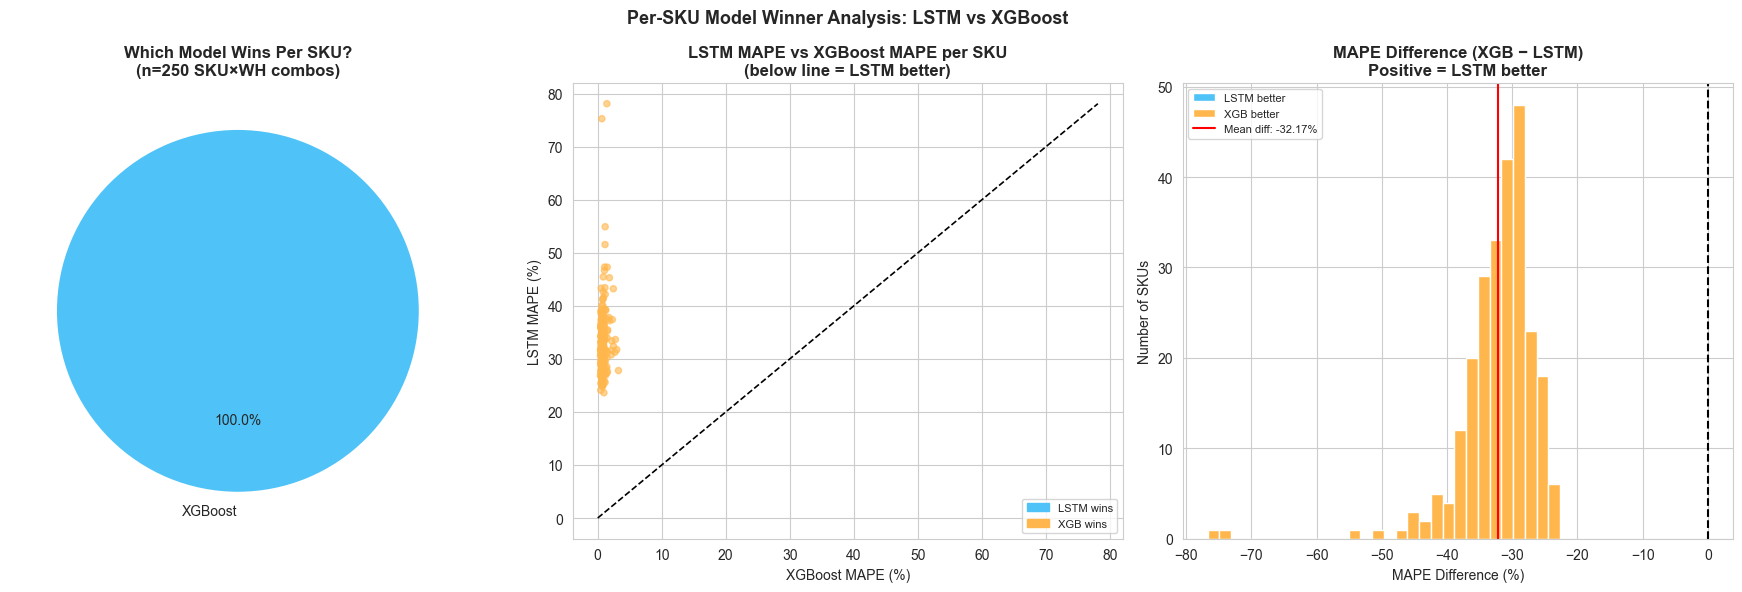

  LSTM wins  : 0 SKUs  (0.0%)
  XGB  wins  : 250 SKUs  (100.0%)
✅ SKU winner analysis saved.


In [7]:
# ─────────────────────────────────────────────────────────────
# SECTION 7: PER-SKU WINNER ANALYSIS
# ─────────────────────────────────────────────────────────────

merged_sku = pd.merge(
    lstm_sku[['SKU_ID','Warehouse_ID','MAPE']].rename(columns={'MAPE':'LSTM_MAPE'}),
    xgb_sku [['SKU_ID','Warehouse_ID','MAPE']].rename(columns={'MAPE':'XGB_MAPE'}),
    on=['SKU_ID','Warehouse_ID'], how='inner'
)

merged_sku['Winner']       = np.where(merged_sku['LSTM_MAPE'] < merged_sku['XGB_MAPE'], 'LSTM', 'XGBoost')
merged_sku['MAPE_Diff']    = merged_sku['XGB_MAPE'] - merged_sku['LSTM_MAPE']   # positive = LSTM wins
merged_sku['Best_MAPE']    = merged_sku[['LSTM_MAPE','XGB_MAPE']].min(axis=1)

winner_counts = merged_sku['Winner'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── 1. Winner pie ──
axes[0].pie(winner_counts, labels=winner_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=['#4FC3F7','#FFB74D'],
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title(f'Which Model Wins Per SKU?\n(n={len(merged_sku)} SKU×WH combos)')

# ── 2. MAPE scatter LSTM vs XGB ──
axes[1].scatter(
    merged_sku['XGB_MAPE'], merged_sku['LSTM_MAPE'],
    c=merged_sku['Winner'].map({'LSTM':'#4FC3F7','XGBoost':'#FFB74D'}),
    alpha=0.6, s=20
)
lim = max(merged_sku[['LSTM_MAPE','XGB_MAPE']].max())
axes[1].plot([0,lim],[0,lim],'k--',lw=1.2, label='Equal performance')
axes[1].set_title('LSTM MAPE vs XGBoost MAPE per SKU\n(below line = LSTM better)')
axes[1].set_xlabel('XGBoost MAPE (%)')
axes[1].set_ylabel('LSTM MAPE (%)')
axes[1].legend(fontsize=8)
lstm_patch = mpatches.Patch(color='#4FC3F7', label='LSTM wins')
xgb_patch  = mpatches.Patch(color='#FFB74D', label='XGB wins')
axes[1].legend(handles=[lstm_patch, xgb_patch], fontsize=8)

# ── 3. MAPE difference distribution ──
# Use shared bins and plot positive (LSTM better) vs negative (XGB better) separately
diff = merged_sku['MAPE_Diff']
bins = np.linspace(diff.min(), diff.max(), 31)
axes[2].hist(diff[diff >= 0], bins=bins, color='#4FC3F7', edgecolor='white', label='LSTM better')
axes[2].hist(diff[diff < 0], bins=bins, color='#FFB74D', edgecolor='white', label='XGB better')
axes[2].axvline(0, color='black', lw=1.5, ls='--')
axes[2].axvline(merged_sku['MAPE_Diff'].mean(), color='red', lw=1.5,
                label=f'Mean diff: {merged_sku["MAPE_Diff"].mean():.2f}%')
axes[2].set_title('MAPE Difference (XGB − LSTM)\nPositive = LSTM better')
axes[2].set_xlabel('MAPE Difference (%)')
axes[2].set_ylabel('Number of SKUs')
axes[2].legend(fontsize=8)

plt.suptitle('Per-SKU Model Winner Analysis: LSTM vs XGBoost',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dashboard_sku_winners.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'  LSTM wins  : {winner_counts.get("LSTM",0)} SKUs  ({winner_counts.get("LSTM",0)/len(merged_sku)*100:.1f}%)')
print(f'  XGB  wins  : {winner_counts.get("XGBoost",0)} SKUs  ({winner_counts.get("XGBoost",0)/len(merged_sku)*100:.1f}%)')
print('✅ SKU winner analysis saved.')

---
## 🏗️ Section 8: Project Architecture Summary

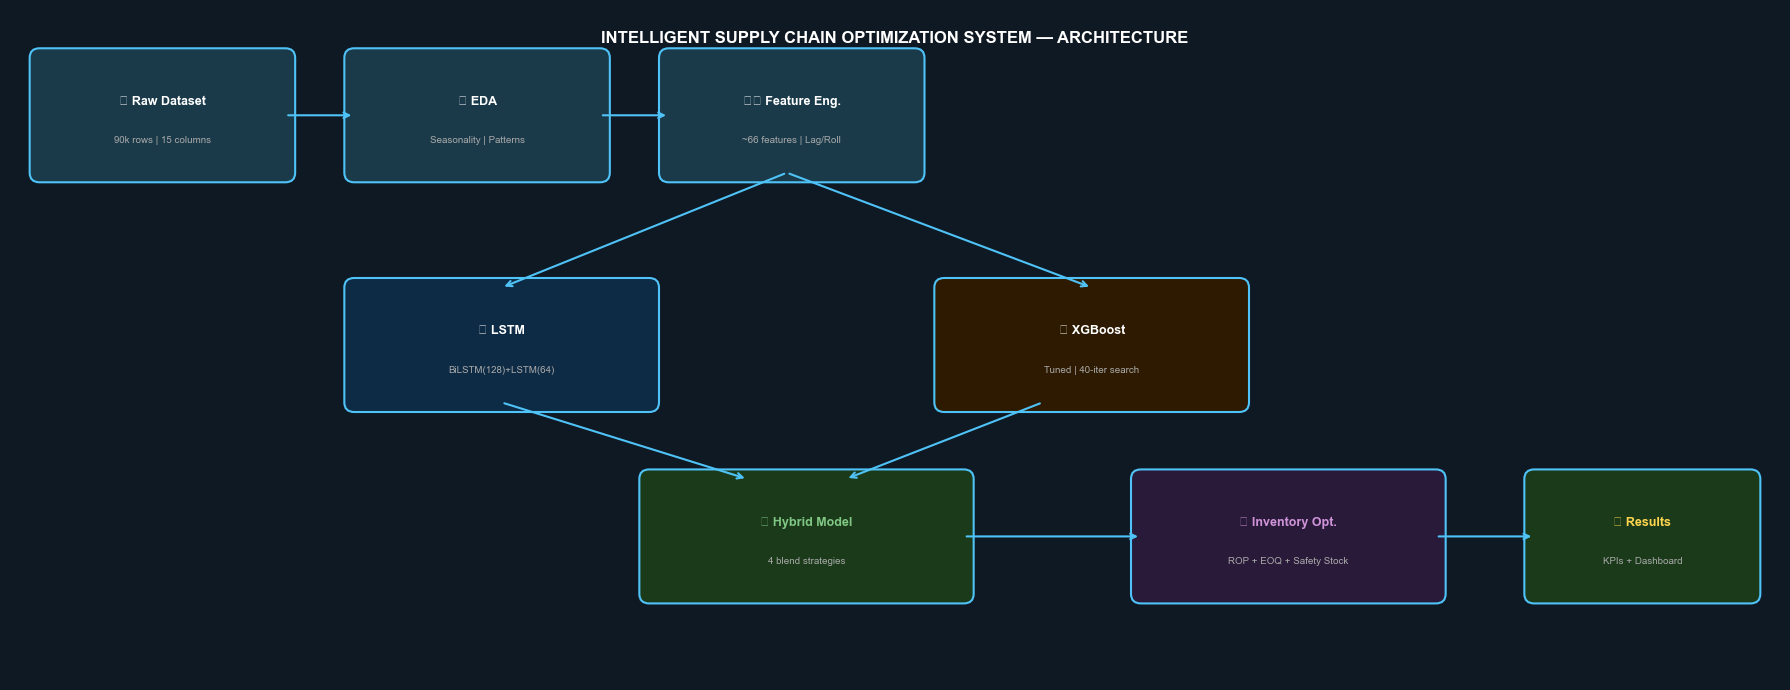

✅ Architecture diagram saved.


In [8]:
# ─────────────────────────────────────────────────────────────
# SECTION 8: PROJECT ARCHITECTURE DIAGRAM
# ─────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(18, 7))
ax.set_xlim(0, 18)
ax.set_ylim(0, 7)
ax.axis('off')
fig.patch.set_facecolor('#0f1923')
ax.set_facecolor('#0f1923')

def draw_box(ax, x, y, w, h, label, sublabel='', color='#1a2634', textcolor='white', fontsize=9):
    rect = mpatches.FancyBboxPatch((x, y), w, h,
        boxstyle='round,pad=0.1', facecolor=color, edgecolor='#4FC3F7', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x+w/2, y+h*0.62, label,    ha='center', va='center',
            fontsize=fontsize, fontweight='bold', color=textcolor)
    if sublabel:
        ax.text(x+w/2, y+h*0.28, sublabel, ha='center', va='center',
                fontsize=7, color='#aaaaaa')

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
        arrowprops=dict(arrowstyle='->', color='#4FC3F7', lw=1.5))

# Row 1: Data
draw_box(ax, 0.3, 5.3, 2.5, 1.2, '📦 Raw Dataset',    '90k rows | 15 columns', '#1a3a4a')
draw_arrow(ax, 2.8, 5.9, 3.5, 5.9)
draw_box(ax, 3.5, 5.3, 2.5, 1.2, '🔍 EDA',            'Seasonality | Patterns', '#1a3a4a')
draw_arrow(ax, 6.0, 5.9, 6.7, 5.9)
draw_box(ax, 6.7, 5.3, 2.5, 1.2, '⚙️ Feature Eng.',   '~66 features | Lag/Roll', '#1a3a4a')

# Row 2: Models
draw_arrow(ax, 7.9, 5.3, 5.0, 4.1)
draw_arrow(ax, 7.9, 5.3, 11.0, 4.1)
draw_box(ax, 3.5, 2.9, 3.0, 1.2, '🧠 LSTM',           'BiLSTM(128)+LSTM(64)', '#0d2b45')
draw_box(ax, 9.5, 2.9, 3.0, 1.2, '🌲 XGBoost',        'Tuned | 40-iter search', '#2d1a00')

# Row 3: Hybrid
draw_arrow(ax, 5.0, 2.9, 7.5, 2.1)
draw_arrow(ax, 10.5, 2.9, 8.5, 2.1)
draw_box(ax, 6.5, 0.9, 3.2, 1.2, '🔗 Hybrid Model',   '4 blend strategies', '#1a3a1a', textcolor='#81C784')

# Row 3: Optimizer
draw_arrow(ax, 9.7, 1.5, 11.5, 1.5)
draw_box(ax, 11.5, 0.9, 3.0, 1.2, '📦 Inventory Opt.','ROP + EOQ + Safety Stock', '#2a1a3a', textcolor='#CE93D8')

# Row 3: Results
draw_arrow(ax, 14.5, 1.5, 15.5, 1.5)
draw_box(ax, 15.5, 0.9, 2.2, 1.2, '📊 Results',       'KPIs + Dashboard', '#1a3a1a', textcolor='#FFD54F')

# Title
ax.text(9, 6.7, 'INTELLIGENT SUPPLY CHAIN OPTIMIZATION SYSTEM — ARCHITECTURE',
        ha='center', va='center', fontsize=12, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('dashboard_architecture.png', dpi=150, bbox_inches='tight',
            facecolor='#0f1923', edgecolor='none')
plt.show()
print('✅ Architecture diagram saved.')

---
## 📋 Section 9: Full Project Summary Printout

In [9]:
# ─────────────────────────────────────────────────────────────
# SECTION 9: FULL SUMMARY PRINTOUT
# ─────────────────────────────────────────────────────────────

print('=' * 65)
print('  🔗  INTELLIGENT SUPPLY CHAIN OPTIMIZATION SYSTEM')
print('       COMPLETE PROJECT RESULTS SUMMARY')
print('=' * 65)

print('\n  📁 DATASET')
print(f'  Rows          : {len(hybrid_preds) + int(len(hybrid_preds)*0.70/0.15):,} (estimated total)')
print(f'  SKUs          : {hybrid_preds["SKU_ID"].nunique()}')
print(f'  Test Period   : {hybrid_preds["Date"].min().date()} → {hybrid_preds["Date"].max().date()}')

print('\n  🧠 LSTM MODEL')
print(f'  Architecture  : BiLSTM(128) → LSTM(64) → Dense(32) → Dense(1)')
print(f'  MAE           : {lstm_metrics["MAE"]:.4f}')
print(f'  RMSE          : {lstm_metrics["RMSE"]:.4f}')
print(f'  MAPE          : {lstm_metrics["MAPE"]:.2f}%')
print(f'  R²            : {lstm_metrics["R2"]:.4f}')

print('\n  🌲 XGBOOST MODEL')
print(f'  Tuning        : RandomizedSearchCV (40 iter, TimeSeriesSplit)')
print(f'  MAE           : {xgb_metrics["MAE"]:.4f}')
print(f'  RMSE          : {xgb_metrics["RMSE"]:.4f}')
print(f'  MAPE          : {xgb_metrics["MAPE"]:.2f}%')
print(f'  R²            : {xgb_metrics["R2"]:.4f}')

print('\n  🔗 HYBRID MODEL')
print(f'  Best Strategy : {hybrid_metrics.get("best_strategy")}')
print(f'  MAE           : {hybrid_metrics["MAE"]:.4f}')
print(f'  RMSE          : {hybrid_metrics["RMSE"]:.4f}')
print(f'  MAPE          : {hybrid_metrics["MAPE"]:.2f}%')
print(f'  R²            : {hybrid_metrics["R2"]:.4f}')

print('\n  📦 INVENTORY OPTIMIZATION')
print(f'  Method        : Dynamic ROP + EOQ + Safety Stock (Z=1.645)')
print(f'  Service Level : {biz_value["service_level_target"]*100:.0f}%')

print('\n  💰 BUSINESS VALUE')
print(f'  Cost Saving   : ${biz_value["cost_saving_vs_original"]:,.2f}  ({biz_value["pct_cost_saving"]:+.1f}%)')
print(f'  Stockout Days : -{biz_value["stockout_days_reduction"]} days  ({biz_value["pct_stockout_reduction"]:.1f}% reduction)')
print(f'  Avg Inventory : {biz_value["avg_inventory_change"]:+.1f} units change')

print('\n' + '=' * 65)
print('  ✅  Project Complete — 8/8 Notebooks Done')
print('=' * 65)

  🔗  INTELLIGENT SUPPLY CHAIN OPTIMIZATION SYSTEM
       COMPLETE PROJECT RESULTS SUMMARY

  📁 DATASET
  Rows          : 34,000 (estimated total)
  SKUs          : 50
  Test Period   : 2024-12-07 → 2024-12-30

  🧠 LSTM MODEL
  Architecture  : BiLSTM(128) → LSTM(64) → Dense(32) → Dense(1)
  MAE           : 6.2848
  RMSE          : 7.7264
  MAPE          : 33.04%
  R²            : -0.9824

  🌲 XGBOOST MODEL
  Tuning        : RandomizedSearchCV (40 iter, TimeSeriesSplit)
  MAE           : 0.0915
  RMSE          : 0.1577
  MAPE          : 0.87%
  R²            : 0.9993

  🔗 HYBRID MODEL
  Best Strategy : XGBoost
  MAE           : 0.1048
  RMSE          : 0.1823
  MAPE          : 0.70%
  R²            : 0.9989

  📦 INVENTORY OPTIMIZATION
  Method        : Dynamic ROP + EOQ + Safety Stock (Z=1.645)
  Service Level : 95%

  💰 BUSINESS VALUE
  Cost Saving   : $104,446.40  (+15.4%)
  Stockout Days : -0 days  (0.0% reduction)
  Avg Inventory : -460.0 units change

  ✅  Project Complete — 8/8 Not

---
## 🌐 Section 10: Export HTML Report

In [10]:
# ─────────────────────────────────────────────────────────────
# SECTION 10: EXPORT HTML REPORT
# ─────────────────────────────────────────────────────────────
# Generates a self-contained HTML dashboard you can open in
# any browser or share with stakeholders.
# ─────────────────────────────────────────────────────────────

import base64

def img_to_base64(path):
    try:
        with open(path, 'rb') as f:
            return base64.b64encode(f.read()).decode()
    except FileNotFoundError:
        return ''

imgs = {
    'kpi'         : img_to_base64('dashboard_kpi.png'),
    'models'      : img_to_base64('dashboard_model_comparison.png'),
    'hybrid'      : img_to_base64('dashboard_hybrid_deepdive.png'),
    'inventory'   : img_to_base64('dashboard_inventory_impact.png'),
    'waterfall'   : img_to_base64('dashboard_waterfall.png'),
    'sku_winners' : img_to_base64('dashboard_sku_winners.png'),
    'arch'        : img_to_base64('dashboard_architecture.png'),
}

html = f"""
<!DOCTYPE html>
<html lang="en">
<head>
  <meta charset="UTF-8">
  <title>Supply Chain Optimization Dashboard</title>
  <style>
    body  {{ font-family: 'Segoe UI', Arial, sans-serif; background:#0f1923; color:#e0e0e0; margin:0; padding:20px; }}
    h1    {{ color:#4FC3F7; text-align:center; font-size:1.6em; margin-bottom:4px; }}
    h2    {{ color:#81C784; font-size:1.1em; border-bottom:1px solid #333; padding-bottom:4px; margin-top:30px; }}
    .sub  {{ color:#888; text-align:center; font-size:0.85em; margin-bottom:20px; }}
    .img-block {{ text-align:center; margin:16px 0; }}
    img   {{ max-width:100%; border-radius:8px; border:1px solid #2a3a4a; }}
    .footer {{ text-align:center; color:#555; font-size:0.8em; margin-top:40px; }}
  </style>
</head>
<body>
  <h1>🔗 Intelligent Supply Chain Optimization System</h1>
  <p class="sub">Results Dashboard | Hybrid LSTM + XGBoost Demand Forecasting + Inventory Optimization</p>

  <h2>🎯 Executive KPI Dashboard</h2>
  <div class="img-block"><img src="data:image/png;base64,{imgs['kpi']}" /></div>

  <h2>🏗️ System Architecture</h2>
  <div class="img-block"><img src="data:image/png;base64,{imgs['arch']}" /></div>

  <h2>📊 Forecast Model Comparison</h2>
  <div class="img-block"><img src="data:image/png;base64,{imgs['models']}" /></div>

  <h2>🔬 Hybrid Model Deep-Dive</h2>
  <div class="img-block"><img src="data:image/png;base64,{imgs['hybrid']}" /></div>

  <h2>🥊 Per-SKU Winner: LSTM vs XGBoost</h2>
  <div class="img-block"><img src="data:image/png;base64,{imgs['sku_winners']}" /></div>

  <h2>🏭 Inventory Policy Impact</h2>
  <div class="img-block"><img src="data:image/png;base64,{imgs['inventory']}" /></div>

  <h2>💰 Business Value Waterfall</h2>
  <div class="img-block"><img src="data:image/png;base64,{imgs['waterfall']}" /></div>

  <div class="footer">
    Intelligent Supply Chain Optimization System &nbsp;|&nbsp;
    Best Strategy: {hybrid_metrics.get('best_strategy','—')} &nbsp;|&nbsp;
    Cost Saving: ${biz_value['cost_saving_vs_original']:,.2f}
  </div>
</body>
</html>
"""

with open('supply_chain_dashboard.html', 'w', encoding='utf-8') as f:
    f.write(html)

print('✅ HTML dashboard exported: supply_chain_dashboard.html')
print('   Open in any browser to view the full report.')
print()
print('🎉 All 8 notebooks complete!')
print('   Project: Intelligent Supply Chain Optimization System')
print('   Files generated: 30+ CSVs, JSONs, PKLs, PNGs, HTML')

✅ HTML dashboard exported: supply_chain_dashboard.html
   Open in any browser to view the full report.

🎉 All 8 notebooks complete!
   Project: Intelligent Supply Chain Optimization System
   Files generated: 30+ CSVs, JSONs, PKLs, PNGs, HTML


---
## ✅ Notebook 08 Summary

| Section | Output |
|---|---|
| Executive KPI Dashboard | Dark-theme 6-panel KPI card |
| Model Comparison | All 7 models × 4 metrics bar chart |
| Hybrid Deep-Dive | Timeline, scatter, error over time, residual KDE |
| Inventory Impact | Cost breakdown, stockout days, avg inventory |
| Business Value Waterfall | Cost savings breakdown by category |
| SKU Winner Analysis | LSTM vs XGBoost per-SKU pie, scatter, histogram |
| Architecture Diagram | Full system flow dark-theme diagram |
| HTML Export | Self-contained shareable report |

**Saved files:**
- `dashboard_kpi.png`
- `dashboard_model_comparison.png`
- `dashboard_hybrid_deepdive.png`
- `dashboard_inventory_impact.png`
- `dashboard_waterfall.png`
- `dashboard_sku_winners.png`
- `dashboard_architecture.png`
- `supply_chain_dashboard.html` ← **shareable report**

---
## 🎉 PROJECT COMPLETE — 8/8 Notebooks Done

| Notebook | Title |
|---|---|
| 01 | Data Loading & Validation |
| 02 | Exploratory Data Analysis |
| 03 | Feature Engineering |
| 04 | LSTM Demand Forecasting |
| 05 | XGBoost Demand Forecasting |
| 06 | Hybrid Model (Blending) |
| 07 | Inventory Optimization |
| 08 | Results Dashboard ✅ |

---
*Intelligent Supply Chain Optimization System | Notebook 08 of 08*